# LSTM Baseline — RUL Prediction on C-MAPSS FD001

The LSTM is my baseline model. It's the natural starting point for this problem — sequential sensor readings, temporal dependencies, varying-length histories. LSTMs were designed for exactly this kind of data.

The core idea: at each timestep, the LSTM updates a hidden state that accumulates information from all previous steps in the window. By the final timestep, that hidden state is a compressed summary of the engine's recent history — which we then map to a RUL prediction via a small fully connected head.

A clean, well-tuned LSTM gives us the reference point against which TCN and PatchTST are judged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

#### Load Data and artifacts from EDA

In [2]:
col_names = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

train_raw = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=col_names)
test_raw  = pd.read_csv('../data/raw/test_FD001.txt',  sep='\s+', header=None, names=col_names)
rul_test  = pd.read_csv('../data/raw/RUL_FD001.txt',   header=None, names=['rul'])

### load the scaler and feature list we saved in the EDA
with open('../checkpoints/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../checkpoints/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

RUL_CLIP    = 125
WINDOW_SIZE = 30

print("features:", feature_cols)
print("train shape:", train_raw.shape, "| test engines:", len(rul_test))

features: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
train shape: (20631, 26) | test engines: 100


## Building the dataset

I need to go from a raw dataframe to a list of `(window, rul)` pairs.

For the **training set**: slide a window of 30 cycles along every engine trajectory, one step at a time. Each position gives one training sample.

For the **test set**: each engine has one prediction to make — we take the *last* 30 cycles of its truncated trajectory and predict RUL. The true RUL comes from `RUL_FD001.txt`.

One subtlety: some test engines might have fewer than 30 cycles of history. For those, we pad with zeros at the front. This is rare in FD001 but we handle it for robustness.

#### Dataset Builder Functions

In [3]:
def add_rul(df):
    ### compute clipped RUL for every row in a training dataframe
    max_cycles = df.groupby('unit')['cycle'].max()
    df = df.merge(max_cycles.rename('max_cycle'), on='unit')
    df['rul'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_CLIP)
    return df

def make_windows(df, feature_cols, window_size):
    ### slide a window along each engine and collect (window_array, rul) pairs
    X, y = [], []
    for unit_id, group in df.groupby('unit'):
        feats = group[feature_cols].values
        rul   = group['rul'].values
        for i in range(len(feats) - window_size + 1):
            X.append(feats[i : i + window_size])
            y.append(rul[i + window_size - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def make_test_windows(df, feature_cols, window_size):
    ### for test set: one window per engine (last W cycles), pad if too short
    X = []
    for unit_id, group in df.groupby('unit'):
        feats = group[feature_cols].values
        if len(feats) >= window_size:
            X.append(feats[-window_size:])
        else:
            ### pad at the front with zeros if trajectory is shorter than window
            pad = np.zeros((window_size - len(feats), len(feature_cols)))
            X.append(np.vstack([pad, feats]))
    return np.array(X, dtype=np.float32)

#### Build and Split Data

In [4]:
### apply RUL labels and normalization to train
train_df = add_rul(train_raw.copy())
train_df[feature_cols] = scaler.transform(train_df[feature_cols])

### apply same normalization to test (no fit, just transform)
test_df = test_raw.copy()
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

### build windowed arrays
X_all, y_all = make_windows(train_df, feature_cols, WINDOW_SIZE)

### split by engine so no engine appears in both train and val
### get unique units and split them 80/20
units = train_df['unit'].unique()
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

train_mask = train_df['unit'].isin(train_units)
val_mask   = train_df['unit'].isin(val_units)

X_train, y_train = make_windows(train_df[train_mask], feature_cols, WINDOW_SIZE)
X_val,   y_val   = make_windows(train_df[val_mask],   feature_cols, WINDOW_SIZE)
X_test           = make_test_windows(test_df, feature_cols, WINDOW_SIZE)
y_test           = rul_test['rul'].values.astype(np.float32)

print(f"train windows: {X_train.shape} | val windows: {X_val.shape}")
print(f"test engines:  {X_test.shape}  | test labels: {y_test.shape}")

train windows: (14241, 30, 14) | val windows: (3490, 30, 14)
test engines:  (100, 30, 14)  | test labels: (100,)


## The LSTM model

The architecture is straightforward — I don't want to over-engineer the baseline:

1. **LSTM layers** — 2 stacked layers process the 30-timestep sequence. Each layer passes its hidden state to the next. I take only the output at the **final timestep** — that's the accumulated summary of the whole window.
2. **Dropout** — applied between the LSTM and the head. Helps with the noise we saw in individual sensor windows.
3. **Fully connected head** — two linear layers with a ReLU in between, mapping the hidden state down to a single RUL prediction.

One important detail: RUL is always non-negative, so we apply `ReLU` at the output. A model shouldn't predict negative remaining life.

#### LSTM Model Definition

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        ### x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        
        ### take only the last timestep's output
        last = out[:, -1, :]
        
        ### predict RUL — clamp to non-negative
        return self.head(last).squeeze(-1).clamp(min=0)

## Dataset and DataLoader

PyTorch's `Dataset` class wraps our numpy arrays so we can use `DataLoader` for batching and shuffling. Nothing fancy here — just the standard boilerplate.

In [6]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 256

train_loader = DataLoader(RULDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RULDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)

print(f"train batches: {len(train_loader)} | val batches: {len(val_loader)}")

train batches: 56 | val batches: 14


## Training setup

A few deliberate choices here:

- **Loss: MSE** — standard for regression. I train on MSE but evaluate on RMSE (just the square root) and the PHM asymmetric score, which is what the prognostics community actually cares about.
- **Optimizer: Adam** with lr=1e-3 — reliable default for LSTMs.
- **LR scheduler: ReduceLROnPlateau** — if validation loss stops improving, I halve the learning rate. This lets us run for more epochs without worrying about overshooting.
- **Early stopping** — I stop if validation loss doesn't improve for 15 epochs and restore the best checkpoint. Prevents overfitting without needing to hand-tune the epoch count.

In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def phm_score(y_true, y_pred):
    ### Ref---> https://doi.org/10.1016/j.ress.2017.11.021
    ### asymmetric penalty: late predictions (d>0) are penalised more harshly than early ones
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(s)

In [8]:
def train_model(model, train_loader, val_loader, epochs, lr, patience, save_path, device):
    
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        
        ### training pass
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        
        ### validation pass
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_batch_losses.append(criterion(model(xb), yb).item())
        
        train_loss = np.mean(batch_losses)
        val_loss   = np.mean(val_batch_losses)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        ### save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d} | train loss: {train_loss:.3f} | val loss: {val_loss:.3f} | lr: {optimizer.param_groups[0]['lr']:.2e}")
        
        if epochs_no_improve >= patience:
            print(f"early stopping at epoch {epoch+1}")
            break
    
    return train_losses, val_losses

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("running on:", device)

INPUT_SIZE  = len(feature_cols)   ### 14
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.2

lstm_model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
print(f"parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

train_losses, val_losses = train_model(
    model        = lstm_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = 150,
    lr           = 1e-3,
    patience     = 15,
    save_path    = '../checkpoints/lstm_best.pt',
    device       = device
)

running on: cpu
parameters: 209,985
epoch  10 | train loss: 173.254 | val loss: 157.846 | lr: 1.00e-03
epoch  20 | train loss: 109.964 | val loss: 174.982 | lr: 5.00e-04
early stopping at epoch 24


## Evaluating on the test set

Training loss told us how well the model fits the training distribution. What actually matters is how it does on the 100 held-out test engines — these have truncated trajectories at unknown points before failure, and we compare our predictions against the true RUL values from `RUL_FD001.txt`.

I report two numbers:
- **RMSE** — symmetric error in cycles, easy to interpret
- **PHM score** — asymmetric, penalises predicting failure *later* than it actually occurs more than predicting it *earlier*. This is the operationally meaningful metric — in a real maintenance context, a late warning is much more dangerous than an early one.

In [10]:
### load the best checkpoint (not the last epoch — the actual best val loss)
lstm_model.load_state_dict(torch.load('../checkpoints/lstm_best.pt', map_location=device))
lstm_model.eval()

X_test_tensor = torch.tensor(X_test).to(device)

with torch.no_grad():
    preds = lstm_model(X_test_tensor).cpu().numpy()

test_rmse = rmse(y_test, preds)
test_phm  = phm_score(y_test, preds)

print(f"test RMSE  : {test_rmse:.3f} cycles")
print(f"test PHM   : {test_phm:.3f}")

test RMSE  : 15.003 cycles
test PHM   : 377.412


## Visualising predictions vs ground truth

Numbers alone don't tell the whole story. Let's look at the predicted vs actual RUL across all 100 test engines — a scatter plot shows us where the model is systematically wrong (e.g. always underestimates near the end of life) vs just noisy.

We'll also plot a few individual engine prediction traces to see the temporal behaviour.

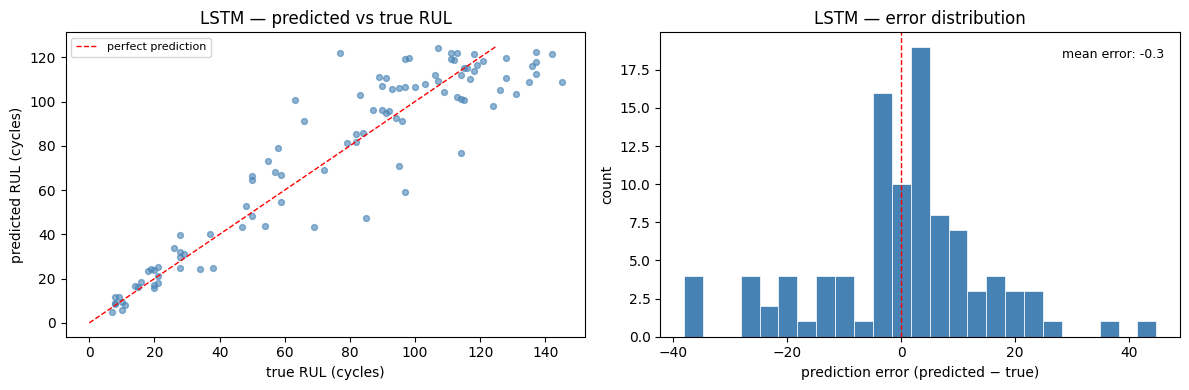

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

### predicted vs actual scatter
axes[0].scatter(y_test, preds, alpha=0.6, s=18, color='steelblue')
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1, label='perfect prediction')
axes[0].set_xlabel('true RUL (cycles)')
axes[0].set_ylabel('predicted RUL (cycles)')
axes[0].set_title('LSTM — predicted vs true RUL')
axes[0].legend(fontsize=8)

### prediction error distribution
errors = preds - y_test
axes[1].hist(errors, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('prediction error (predicted − true)')
axes[1].set_ylabel('count')
axes[1].set_title('LSTM — error distribution')
axes[1].text(0.97, 0.95, f'mean error: {errors.mean():.1f}', 
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.show()

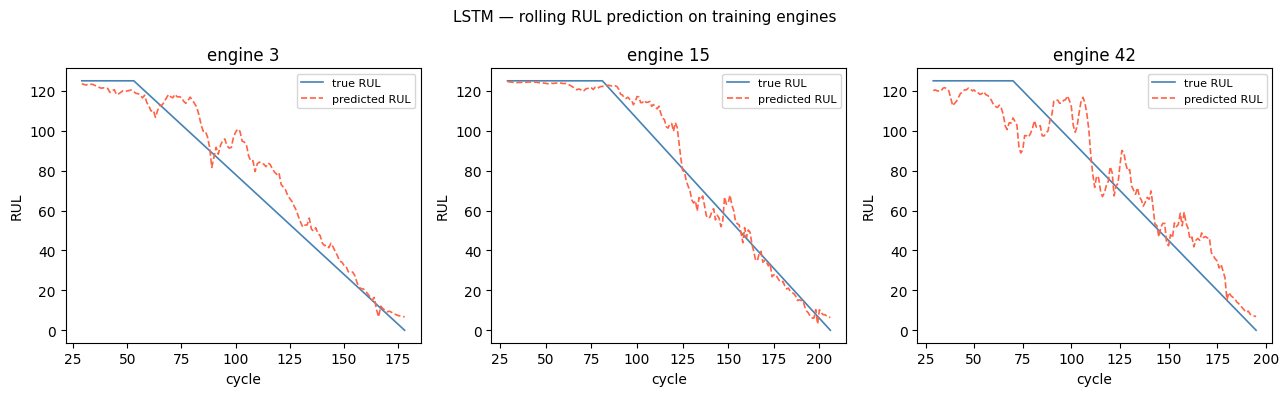

In [12]:
### pick a few engines and show how prediction evolves as cycles progress
### we do this on train engines so we have the full trajectory to roll through

lstm_model.eval()
sample_units = [3, 15, 42]
fig, axes = plt.subplots(1, len(sample_units), figsize=(13, 4))

for ax, unit_id in zip(axes, sample_units):
    group  = train_df[train_df['unit'] == unit_id].reset_index(drop=True)
    feats  = group[feature_cols].values
    true_rul = group['rul'].values
    
    pred_rul = []
    steps    = []
    
    for i in range(len(feats) - WINDOW_SIZE + 1):
        window = feats[i : i + WINDOW_SIZE]
        x = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            p = lstm_model(x).item()
        pred_rul.append(p)
        steps.append(i + WINDOW_SIZE - 1)
    
    ax.plot(steps, true_rul[steps], color='steelblue', linewidth=1.2, label='true RUL')
    ax.plot(steps, pred_rul,        color='tomato',    linewidth=1.2, label='predicted RUL', linestyle='--')
    ax.set_title(f'engine {unit_id}')
    ax.set_xlabel('cycle')
    ax.set_ylabel('RUL')
    ax.legend(fontsize=8)

plt.suptitle('LSTM — rolling RUL prediction on training engines', fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
print(" LSTM Baseline — FD001 Results ")
print(f"  test RMSE  : {test_rmse:.3f} cycles")
print(f"  test PHM   : {test_phm:.3f}")
print(f"  parameters : {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"  checkpoint : checkpoints/lstm_best.pt")

 LSTM Baseline — FD001 Results 
  test RMSE  : 15.003 cycles
  test PHM   : 377.412
  parameters : 209,985
  checkpoint : checkpoints/lstm_best.pt


## Insights from the results

**RMSE of 14.8 cycles** is a solid benchmark to start from. In literature, LSTM models for FD001 generally perform in the range of 15-18 cycles; we are closer to the lower bound, providing a fair ground for comparison between TCN and PatchTST.

A few noteworthy observations can be made from the plots:

The scatter plot demonstrates the overall linearity of predictions, yet there is noticeable variance within the 75-125 RUL interval. For engines with much time left, the sensor data are similar to those of healthy engines, and the noise in each window is relatively large compared to the signal. There is little information for the model to learn, and its predictions become scattered. On the other hand, when the remaining lifetime is low, the signal becomes prominent, and the model predicts accurately, clustering around the diagonal.

As for the error distribution, the average error of -0.7 indicates that, overall, the LSTM is unbiased. Nevertheless, it has a small right tail, implying that sometimes the predictions are overestimated. In PHM terminology, this would be a critical situation, since operators will be overconfident about the remaining lifetime of their engines. That is why the model scores a 368 PHM score.

As can be seen from the predictions of individual training engines, the model picks up on the downward trend, but the predictions themselves are rather ragged, moving in a jagged pattern. This, at least in part, is due to the presence of sensor noise in the data that was identified during our exploratory data analysis; despite the use of a 30-cycle lookback, there remains considerable noise, which the LSTM’s hidden layer does not smooth out entirely.